# $$\text{Single layer A.N.N. exercise}$$

The data is stored in 'dataExercise1.txt', which contains 1000 points. The first three columns represent the input variables, whilst the three last columns represent the output variables.

The Artificial Neural Network (A.N.N.) we want to build

1. Three input and output variables.
2. The activiation function should be defined as rectified linear units (relu).
3. The output layer should be defined by linear activation function (linear).
4. Set the number of neurons and epochs to 50.

#### $$\text{1 - Importing the necessary python modules}$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
from torch import nn
from torch.utils.data import TensorDataset, DataLoader

#### $$\text{2 - Splitting the data}$$

In [2]:
data = np.loadtxt('dataExercise1.txt')

In [3]:
inputData, outputData = data[:, 0:3], data[:, 3:6]

In [4]:
X = torch.tensor(inputData, dtype=torch.float32)
y = torch.tensor(outputData, dtype=torch.float32)

#### $$\text{3 - Creating the single layer A.N.N.}$$

In [5]:
class SingleLayerANN(nn.Module):
    def __init__(self):
        super().__init__()

        self.model = nn.Sequential(
            nn.Linear(3, 50),           # 3 inputs, 50 hidden neurons
            nn.ReLU(),                  # ReLU activation
            nn.Linear(50, 3)            # 3 outputs, linear activation
        )

    def forward(self, x):
        return self.model(x)

The default ``` batch_size ```, if not defined, is the entire dataset tensor passed through the model. Therefore, we use DataLoader to define a matching batch size to TensorFlow (which is by default 32).

In [6]:
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [7]:
model = SingleLayerANN()

In [8]:
lossFunction = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

#### $$\text{4 - Training run}$$

In [9]:
epochs = 50

Before training the model, we call ```model.train()``` to enter into training mode. Apparently some of the layers behaves differently during training and evaluation. 

PyTorch computes the gradient of the loss with respect to each trainable model parameter. ```loss.backward()``` performs backpropagation.

In [10]:
for epoch in range(epochs):
    model.train()

    epoch_loss = 0.0

    for X_batch, y_batch in loader:
        prediction = model(X_batch)

        loss = lossFunction(prediction, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    # print average loss per epoch
    print(f"Epoch {epoch + 1}/{epochs}, Loss: {epoch_loss / len(loader):.6f}")

Epoch 1/50, Loss: 0.080776
Epoch 2/50, Loss: 0.024951
Epoch 3/50, Loss: 0.017265
Epoch 4/50, Loss: 0.012168
Epoch 5/50, Loss: 0.008509
Epoch 6/50, Loss: 0.006772
Epoch 7/50, Loss: 0.005857
Epoch 8/50, Loss: 0.005315
Epoch 9/50, Loss: 0.004940
Epoch 10/50, Loss: 0.004635
Epoch 11/50, Loss: 0.004256
Epoch 12/50, Loss: 0.004029
Epoch 13/50, Loss: 0.003725
Epoch 14/50, Loss: 0.003403
Epoch 15/50, Loss: 0.003186
Epoch 16/50, Loss: 0.002858
Epoch 17/50, Loss: 0.002712
Epoch 18/50, Loss: 0.002453
Epoch 19/50, Loss: 0.002316
Epoch 20/50, Loss: 0.002122
Epoch 21/50, Loss: 0.002042
Epoch 22/50, Loss: 0.001912
Epoch 23/50, Loss: 0.001821
Epoch 24/50, Loss: 0.001688
Epoch 25/50, Loss: 0.001560
Epoch 26/50, Loss: 0.001458
Epoch 27/50, Loss: 0.001388
Epoch 28/50, Loss: 0.001303
Epoch 29/50, Loss: 0.001285
Epoch 30/50, Loss: 0.001163
Epoch 31/50, Loss: 0.001093
Epoch 32/50, Loss: 0.001067
Epoch 33/50, Loss: 0.000995
Epoch 34/50, Loss: 0.000951
Epoch 35/50, Loss: 0.000921
Epoch 36/50, Loss: 0.000861
E

#### $$\text{5 - Visualizing the accuracy}$$

In [11]:
model.eval()

with torch.no_grad():
    prediction = model(X)

prediction_np = prediction.detach().numpy()
y_np = y.detach().numpy()

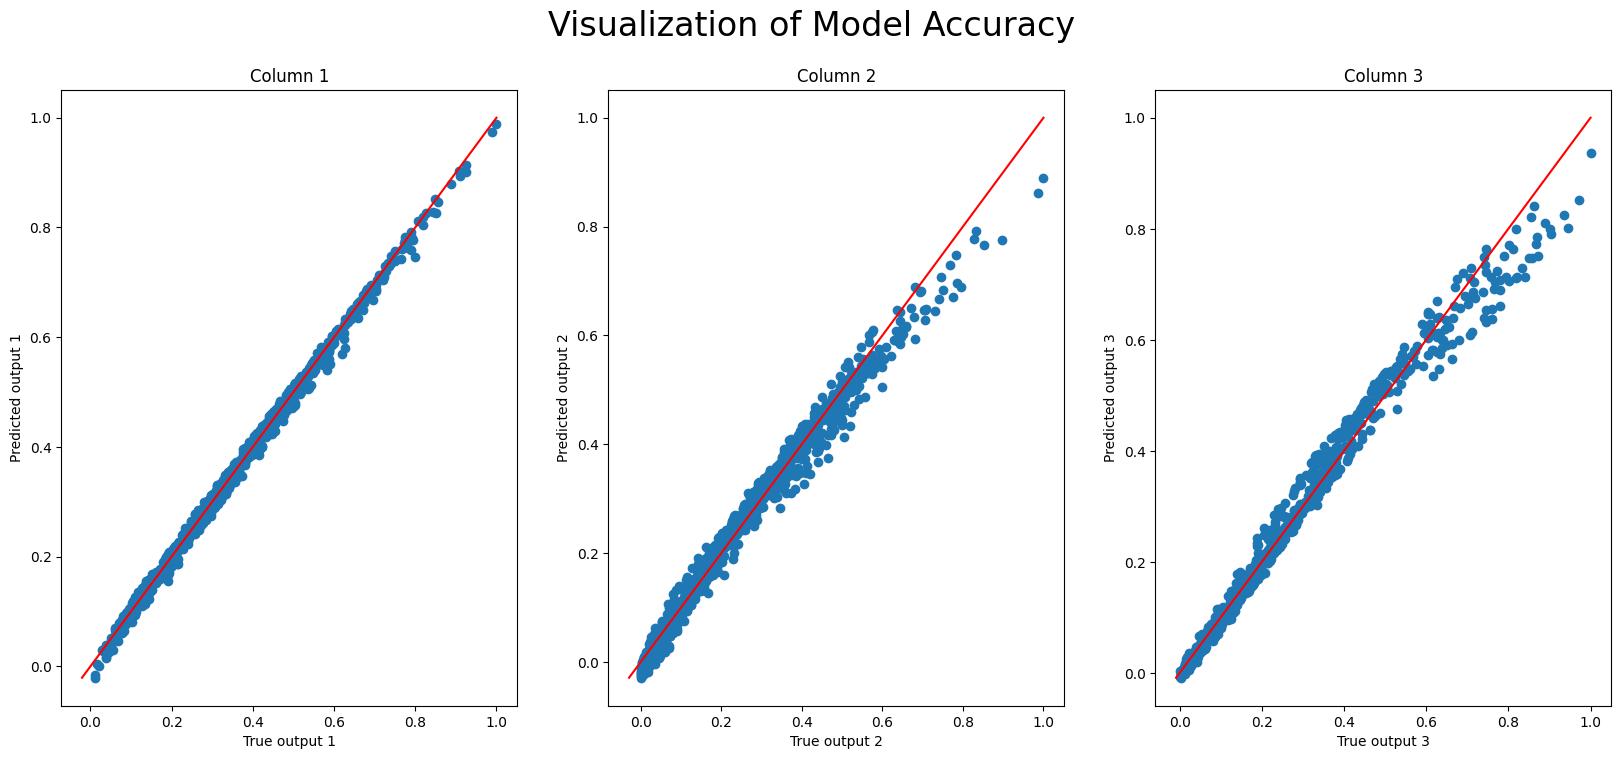

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(20, 8))
fig.suptitle("Visualization of Model Accuracy", fontsize=24)

for i in range(3):
    ax[i].scatter(y_np[:, i], prediction_np[:, i])

    min_val = min(y_np[:, i].min(), prediction_np[:, i].min())
    max_val = max(y_np[:, i].max(), prediction_np[:, i].max())

    ax[i].plot([min_val, max_val], [min_val, max_val], color='r')

    ax[i].set_xlabel(f"True output {i + 1}")
    ax[i].set_ylabel(f"Predicted output {i + 1}")
    ax[i].set_title(f"Column {i + 1}")

plt.show()